# 🚀 Handwriting Recognition: Encoder-Decoder (TrOCR-style)

## 📋 Lessons Learned from CTC Failures:

### ❌ **Why CTC Failed:**
1. **CTC Loss collapse**: Model learns to output blank tokens
   - Loss decreases (17.99 → 0.63) but CER stuck at 98.6%
   - Predictions mostly empty: "", "h", "wh"
   - CTC rewards blank → greedy decode removes them

2. **Monotonic alignment assumption**: CTC assumes strict left-to-right
   - Handwriting has variations, skips, ligatures
   - Hard for CTC to model flexible alignments

3. **No language modeling**: CTC only sees char sequences
   - Can't leverage context ("teh" → "the")
   - Encoder-Decoder with attention learns dependencies

### ✅ **Why Encoder-Decoder Works Better:**
1. **Attention mechanism**: Model learns WHERE to look
   - Can attend to any part of image (not just left-to-right)
   - Handles cursive, overlapping chars, ligatures

2. **Autoregressive decoding**: Uses previous predictions
   - Language modeling built-in
   - Can correct mistakes using context

3. **SOTA accuracy**: TrOCR achieves WER 5-8% vs CTC 10-15%
   - Proven on handwriting benchmarks
   - Used in production systems

## 🎯 Target:
- **CER < 8%** (beat baseline)
- Stable training (no collapse)
- Meaningful predictions from epoch 5+

## 📦 1. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import cv2
import numpy as np
import string
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ============================================================
# 🔧 CONFIG
# ============================================================
IMG_H = 64
IMG_W = 256
BATCH_SIZE = 32
EPOCHS = 50
USE_AMP = True

# Training
LR = 1e-4  # Encoder-Decoder can use higher LR than CTC
WARMUP_EPOCHS = 3
GRAD_CLIP_NORM = 5.0
EARLY_STOP_PATIENCE = 15

# Model architecture
D_MODEL = 256  # Same as CTC version for fair comparison
ENC_LAYERS = 4
DEC_LAYERS = 3  # Decoder can be shallower
NHEAD = 8
FFN_DIM = 1024
DROPOUT = 0.1

# Special tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

print(f"\n✅ Config:")
print(f"   Image: {IMG_H}x{IMG_W}")
print(f"   Batch: {BATCH_SIZE}, Epochs: {EPOCHS}")
print(f"   Model: d_model={D_MODEL}, enc={ENC_LAYERS}, dec={DEC_LAYERS}")
print(f"   LR: {LR:.2e}, Warmup: {WARMUP_EPOCHS} epochs")
print('='*60)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


🔥 Device: cuda
   GPU: Tesla P100-PCIE-16GB
   Memory: 17.06 GB

✅ Config:
   Image: 64x256
   Batch: 32, Epochs: 50
   Model: d_model=256, enc=4, dec=3
   LR: 1.00e-04, Warmup: 3 epochs


## 🏗️ 2. Model Architecture

In [2]:
def levenshtein_distance(s1, s2):
    """Calculate edit distance between two strings"""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]  # Return int, not ratio!


class PositionalEncoding2D(nn.Module):
    """2D positional encoding for image features (H x W)"""
    def __init__(self, d_model, max_h=100, max_w=1000):
        super().__init__()
        self.d_model = d_model
        
        # Create 2D positional encodings [max_h, max_w, d_model]
        pe = torch.zeros(max_h, max_w, d_model)
        
        # Split d_model in half for height and width
        d_h = d_model // 2
        
        # Height encoding (first half) - [max_h, d_h//2]
        pos_h = torch.arange(0, max_h).unsqueeze(1).float()  # [max_h, 1]
        div_term_h = torch.exp(torch.arange(0, d_h, 2).float() * (-math.log(10000.0) / d_h))  # [d_h//2]
        
        sin_h = torch.sin(pos_h * div_term_h)  # [max_h, d_h//2]
        cos_h = torch.cos(pos_h * div_term_h)  # [max_h, d_h//2]
        
        # Broadcast to all width positions
        pe[:, :, 0:d_h:2] = sin_h.unsqueeze(1).expand(-1, max_w, -1)
        pe[:, :, 1:d_h:2] = cos_h.unsqueeze(1).expand(-1, max_w, -1)
        
        # Width encoding (second half) - [max_w, d_h//2]
        pos_w = torch.arange(0, max_w).unsqueeze(1).float()  # [max_w, 1]
        div_term_w = torch.exp(torch.arange(0, d_h, 2).float() * (-math.log(10000.0) / d_h))  # [d_h//2]
        
        sin_w = torch.sin(pos_w * div_term_w)  # [max_w, d_h//2]
        cos_w = torch.cos(pos_w * div_term_w)  # [max_w, d_h//2]
        
        # Broadcast to all height positions
        pe[:, :, d_h::2] = sin_w.unsqueeze(0).expand(max_h, -1, -1)
        pe[:, :, d_h+1::2] = cos_w.unsqueeze(0).expand(max_h, -1, -1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape
        # pe: [H, W, C] → [B, H, W, C] → [B, C, H, W]
        pos_enc = self.pe[:H, :W, :].unsqueeze(0).permute(0, 3, 1, 2)
        return x + pos_enc.to(x.device)


class PositionalEncoding1D(nn.Module):
    """1D positional encoding for decoder (sequence position)"""
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]
    
    def forward(self, x):
        # x: [B, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]


class SimplifiedCNN(nn.Module):
    """CNN backbone (same as CTC version)"""
    def __init__(self, d_model=256):
        super().__init__()
        # 4 conv blocks: 1 → 64 → 128 → 256 → d_model
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2, 2)  # 64x256 → 32x128
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2, 2)  # 32x128 → 16x64
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d((2, 1))  # 16x64 → 8x64 (keep width)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.GELU()
            # NO pooling → output 8x64
        )
    
    def forward(self, x):
        # x: [B, 1, 64, 256]
        x = self.conv1(x)  # [B, 64, 32, 128]
        x = self.conv2(x)  # [B, 128, 16, 64]
        x = self.conv3(x)  # [B, 256, 8, 64]
        x = self.conv4(x)  # [B, d_model, 8, 64]
        return x


class EncoderDecoderHTR(nn.Module):
    """Transformer Encoder-Decoder for Handwriting Recognition"""
    def __init__(self, vocab_size, d_model=256, enc_layers=4, dec_layers=3,
                 nhead=8, ffn_dim=1024, dropout=0.1, max_seq_len=50):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        # CNN backbone
        self.backbone = SimplifiedCNN(d_model)
        
        # Positional encodings
        self.pos_enc_2d = PositionalEncoding2D(d_model)
        self.pos_enc_1d = PositionalEncoding1D(d_model, max_len=max_seq_len)
        
        # Token embedding for decoder
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Transformer Encoder (processes image features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=enc_layers)
        
        # Transformer Decoder (generates text autoregressively)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=dec_layers)
        
        # Output projection
        self.output_proj = nn.Linear(d_model, vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Better initialization (TrOCR-style)"""
        # Linear layers: truncated normal
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def encode(self, images):
        """Encode image to features"""
        # CNN: [B, 1, H, W] → [B, C, h, w]
        features = self.backbone(images)
        
        # Add 2D positional encoding
        features = self.pos_enc_2d(features)
        
        # Flatten: [B, C, h, w] → [B, h*w, C]
        B, C, h, w = features.shape
        features = features.flatten(2).transpose(1, 2)
        
        # Transformer encoder
        memory = self.encoder(features)
        return memory
    
    def decode(self, tgt_tokens, memory, tgt_mask=None, tgt_key_padding_mask=None):
        """Decode text from memory"""
        # Embed tokens: [B, seq_len] → [B, seq_len, d_model]
        tgt_emb = self.token_embedding(tgt_tokens) * math.sqrt(self.d_model)
        
        # Add 1D positional encoding
        tgt_emb = self.pos_enc_1d(tgt_emb)
        
        # Transformer decoder (with cross-attention to encoder memory)
        output = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        
        # Project to vocabulary
        logits = self.output_proj(output)
        return logits
    
    def forward(self, images, tgt_tokens, tgt_mask=None, tgt_key_padding_mask=None):
        """Full forward pass (teacher forcing)"""
        memory = self.encode(images)
        logits = self.decode(tgt_tokens, memory, tgt_mask, tgt_key_padding_mask)
        return logits
    
    def generate(self, images, sos_idx, eos_idx, max_len=50):
        """Greedy decoding (inference) - FIXED: per-sample EOS tracking"""
        self.eval()
        with torch.no_grad():
            memory = self.encode(images)
            B = images.size(0)
            
            # Start with <SOS>
            tgt_tokens = torch.full((B, 1), sos_idx, dtype=torch.long, device=images.device)
            finished = torch.zeros(B, dtype=torch.bool, device=images.device)
            
            for _ in range(max_len):
                # Generate causal mask
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_tokens.size(1)).to(images.device)
                
                # Decode
                logits = self.decode(tgt_tokens, memory, tgt_mask=tgt_mask)
                
                # Get next token (greedy)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                
                # Mark finished sequences (found EOS)
                finished = finished | (next_token.squeeze(1) == eos_idx)
                
                # Append to sequence (replace with PAD if already finished)
                next_token_masked = next_token.clone()
                next_token_masked[finished] = sos_idx  # Use SOS as dummy (will be ignored in decode)
                tgt_tokens = torch.cat([tgt_tokens, next_token_masked], dim=1)
                
                # Stop if all sequences finished
                if finished.all():
                    break
            
            return tgt_tokens


print('='*60)
print('✅ Model architecture defined')
print('   Encoder: CNN + Transformer Encoder (4 layers)')
print('   Decoder: Transformer Decoder (3 layers) with cross-attention')
print('   Output: Autoregressive generation with <SOS>/<EOS>')
print('='*60)

✅ Model architecture defined
   Encoder: CNN + Transformer Encoder (4 layers)
   Decoder: Transformer Decoder (3 layers) with cross-attention
   Output: Autoregressive generation with <SOS>/<EOS>


## 📊 3. Dataset (IAM Words)

In [3]:
print('='*60)
print('📂 LOADING IAM WORDS DATASET')
print('='*60)

# ============================================================
# Dataset paths (Kaggle or Local)
# ============================================================
# Kaggle paths
IAM_ROOT = '/kaggle/input/iam-handwriting-word-database'
WORDS_FILE_ROOT = '/kaggle/input/iam-handwriting-word-database4'
words_txt = os.path.join(WORDS_FILE_ROOT, 'iam_words', 'words.txt')

# Local paths (uncomment if running locally)
# IAM_ROOT = r'D:\IAM'
# WORDS_FILE_ROOT = r'D:\IAM\iam_words'
# words_txt = os.path.join(WORDS_FILE_ROOT, 'words.txt')

def parse_iam_words(words_txt, root_dir):
    all_samples = []
    skipped = {'status': 0, 'chars': 0, 'missing': 0, 'other': 0}
    
    with open(words_txt, 'r', encoding='utf-8') as f:
        lines = [line for line in f if line.strip() and not line.startswith('#')]
        
        for line in tqdm(lines, desc='Parsing IAM'):
            parts = line.split()
            if len(parts) < 9:
                skipped['other'] += 1
                continue
            
            word_id, status, text = parts[0], parts[1], parts[-1].lower()
            if status != 'ok':
                skipped['status'] += 1
                continue
            if '#' in text or '&' in text or not all(c.isalnum() or c.isspace() for c in text):
                skipped['chars'] += 1
                continue
            
            parts_id = word_id.split('-')
            if len(parts_id) < 2:
                skipped['other'] += 1
                continue
            
            folder1 = parts_id[0]
            folder2 = '-'.join(parts_id[:2])
            img_path = os.path.join(root_dir, 'iam_words', 'words', folder1, folder2, f'{word_id}.png')
            
            if not os.path.exists(img_path):
                skipped['missing'] += 1
                continue
            
            all_samples.append((img_path, text))
    
    print(f'\n✅ Loaded: {len(all_samples):,}')
    print(f'   Skipped: {sum(skipped.values()):,}')
    return all_samples

# Load all samples
all_samples = parse_iam_words(words_txt, IAM_ROOT)
max_label_len = max(len(label) for _, label in all_samples)

print(f'   Max label length: {max_label_len}')

# Random split 90/10 (same as CTC version)
all_images = [p for p, l in all_samples]
all_labels = [l for p, l in all_samples]

train_images, val_images, train_labels, val_labels = train_test_split(
    all_images, all_labels, test_size=0.1, random_state=42
)

print(f'\n📊 Split:')
print(f'   Train: {len(train_images):,} samples')
print(f'   Val:   {len(val_images):,} samples')
print('='*60)

📂 LOADING IAM WORDS DATASET


Parsing IAM: 100%|██████████| 115315/115315 [01:56<00:00, 992.70it/s] 


✅ Loaded: 82,733
   Skipped: 32,582
   Max label length: 17

📊 Split:
   Train: 74,459 samples
   Val:   8,274 samples


## 🔤 4. Vocabulary & DataLoader

In [4]:
# Build vocabulary (FIXED: Added space support)
chars = list(string.ascii_lowercase + string.digits + ' ')  # a-z + 0-9 + space
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + chars  # 3 special + 37 chars = 40 total

char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

PAD_IDX = char_to_idx[PAD_TOKEN]
SOS_IDX = char_to_idx[SOS_TOKEN]
EOS_IDX = char_to_idx[EOS_TOKEN]

# Check for space in labels
labels_with_space = sum(' ' in l for l in all_labels)
print(f"📚 Vocabulary: {len(vocab)} tokens (FIXED: added space support)")
print(f"   PAD: {PAD_IDX}, SOS: {SOS_IDX}, EOS: {EOS_IDX}")
print(f"   Chars: {chars[:10]}...")
print(f"   ⚠️  Labels with space: {labels_with_space}/{len(all_labels)}")


def strong_handwriting_augmentation(img):
    """Apply MODERATE augmentation for handwriting (FIXED: reduced prob to avoid over-augmentation)"""
    h, w = img.shape
    
    # 1. Random rotation (-3 to +3 degrees)
    if random.random() < 0.3:  # REDUCED from 0.5
        angle = random.uniform(-3, 3)
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 2. Random shear
    if random.random() < 0.3:  # REDUCED from 0.5
        shear = random.uniform(-0.1, 0.1)
        M = np.array([[1, shear, 0], [0, 1, 0]], dtype=np.float32)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 3. Random scale (0.9x to 1.1x)
    if random.random() < 0.3:  # REDUCED from 0.5
        scale = random.uniform(0.9, 1.1)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        # Pad or crop back to original size
        if new_h < h or new_w < w:
            canvas = np.ones((h, w), dtype=np.uint8) * 255
            y_offset = (h - new_h) // 2
            x_offset = (w - new_w) // 2
            canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img
            img = canvas
        else:
            y_start = (new_h - h) // 2
            x_start = (new_w - w) // 2
            img = img[y_start:y_start+h, x_start:x_start+w]
    
    # 4. Random Gaussian blur
    if random.random() < 0.3:
        kernel_size = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    
    # 5. Random noise
    if random.random() < 0.3:
        noise = np.random.normal(0, 5, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    
    # 6. Random brightness
    if random.random() < 0.3:  # REDUCED from 0.5
        factor = random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)
    
    # 7. Random contrast
    if random.random() < 0.3:  # REDUCED from 0.5
        factor = random.uniform(0.8, 1.2)
        mean = img.mean()
        img = np.clip((img - mean) * factor + mean, 0, 255).astype(np.uint8)
    
    return img


class IAMDataset(Dataset):
    def __init__(self, image_paths, labels, char_to_idx, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.augment = augment
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.ones((IMG_H, IMG_W), dtype=np.uint8) * 255
        
        # Resize
        img = cv2.resize(img, (IMG_W, IMG_H))
        
        # Augment
        if self.augment:
            img = strong_handwriting_augmentation(img)
        
        # Normalize: [0, 255] → [0, 1]
        img = img.astype(np.float32) / 255.0
        img = torch.FloatTensor(img).unsqueeze(0)  # [1, H, W]
        
        # Encode label: "hello" → [SOS, h, e, l, l, o, EOS]
        label = self.labels[idx]
        label_indices = [SOS_IDX] + [self.char_to_idx.get(c, PAD_IDX) for c in label] + [EOS_IDX]
        label_tensor = torch.LongTensor(label_indices)
        
        return img, label_tensor


def collate_fn(batch):
    """Collate function with padding"""
    images, labels = zip(*batch)
    
    # Stack images
    images = torch.stack(images, dim=0)
    
    # Pad labels to same length
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=PAD_IDX)
    
    return images, labels_padded


train_dataset = IAMDataset(train_images, train_labels, char_to_idx, augment=True)
val_dataset = IAMDataset(val_images, val_labels, char_to_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=collate_fn)

print(f"\n✅ DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print('='*60)

📚 Vocabulary: 40 tokens (FIXED: added space support)
   PAD: 0, SOS: 1, EOS: 2
   Chars: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']...
   ⚠️  Labels with space: 0/82733

✅ DataLoaders created
   Train batches: 2327
   Val batches:   259


## 🔧 5. Training Setup

In [5]:
print('='*60)
print('🔥 CREATE ENCODER-DECODER MODEL')
print('='*60)

model = EncoderDecoderHTR(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    enc_layers=ENC_LAYERS,
    dec_layers=DEC_LAYERS,
    nhead=NHEAD,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    max_seq_len=max_label_len + 10  # Add buffer for <SOS>/<EOS>
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
params_per_sample = total_params / len(train_dataset)

print(f"✅ Model created")
print(f"   Total params: {total_params/1e6:.2f}M")
print(f"   Params/sample: {params_per_sample:.1f}")
print(f"   Vocab size: {len(vocab)} (3 special + 36 chars)")
print(f"\n📊 Comparison:")
print(f"   CTC model (failed): 6M params, CER stuck at 98.6%")
print(f"   This model: {total_params/1e6:.1f}M params, Encoder-Decoder architecture")

# Loss: CrossEntropyLoss (ignore padding) - FIXED: Reduced label smoothing for small vocab
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.05)

# Optimizer: AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    weight_decay=0.01
)

# Scheduler: ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-7
)

# Warmup function
def get_warmup_lr(epoch, base_lr, warmup_epochs=3):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

# AMP scaler
if USE_AMP and DEVICE.type == 'cuda':
    try:
        scaler = torch.amp.GradScaler('cuda', growth_interval=2000)
    except AttributeError:
        scaler = torch.cuda.amp.GradScaler(growth_interval=2000)
else:
    scaler = None

print(f"\n✅ Training setup:")
print(f"   Loss: CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Optimizer: AdamW (lr={LR:.2e}, weight_decay=0.01)")
print(f"   Scheduler: ReduceLROnPlateau (patience=5)")
print(f"   Warm-up: {WARMUP_EPOCHS} epochs")
print(f"   AMP: {scaler is not None}")
print('='*60)

🔥 CREATE ENCODER-DECODER MODEL
✅ Model created
   Total params: 7.30M
   Params/sample: 98.0
   Vocab size: 40 (3 special + 36 chars)

📊 Comparison:
   CTC model (failed): 6M params, CER stuck at 98.6%
   This model: 7.3M params, Encoder-Decoder architecture

✅ Training setup:
   Loss: CrossEntropyLoss (label_smoothing=0.1)
   Optimizer: AdamW (lr=1.00e-04, weight_decay=0.01)
   Scheduler: ReduceLROnPlateau (patience=5)
   Warm-up: 3 epochs
   AMP: True


## 🚀 6. Training Loop

In [6]:
def decode_sequence(indices, idx_to_char, remove_special=True):
    """Decode sequence of indices to text"""
    chars = []
    for idx in indices:
        idx = idx.item() if torch.is_tensor(idx) else idx
        if idx == EOS_IDX:
            break
        if remove_special and idx in [PAD_IDX, SOS_IDX]:
            continue
        if idx in idx_to_char:
            chars.append(idx_to_char[idx])
    return ''.join(chars)


def calculate_metrics(predictions, targets, idx_to_char):
    """Calculate CER and WER"""
    total_errors = 0
    total_chars = 0
    total_wer = 0
    
    for pred_indices, target_indices in zip(predictions, targets):
        pred_text = decode_sequence(pred_indices, idx_to_char)
        target_text = decode_sequence(target_indices, idx_to_char)
        
        # CER
        errors = levenshtein_distance(target_text, pred_text)
        total_errors += errors
        total_chars += len(target_text)
        
        # WER
        total_wer += int(pred_text != target_text)
    
    cer = total_errors / max(total_chars, 1)
    wer = total_wer / len(predictions)
    
    return cer, wer


print('='*60)
print('🚀 START TRAINING')
print('='*60 + '\n')

best_val_cer = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    # Warm-up
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = get_warmup_lr(epoch, LR, WARMUP_EPOCHS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
        print(f"🔥 Warm-up epoch {epoch}/{WARMUP_EPOCHS}: LR = {warmup_lr:.2e}")
    
    # ============================================================
    # TRAINING
    # ============================================================
    model.train()
    train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing: input = [SOS, c1, c2, ...], target = [c1, c2, ..., EOS]
        tgt_input = labels[:, :-1]  # Remove last token
        tgt_output = labels[:, 1:]  # Remove <SOS>
        
        # Create causal mask (prevent looking ahead)
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        
        # Create padding mask
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        optimizer.zero_grad()
        
        # Forward pass
        try:
            autocast_context = torch.amp.autocast('cuda' if DEVICE.type == 'cuda' else 'cpu', enabled=USE_AMP)
        except AttributeError:
            autocast_context = torch.cuda.amp.autocast(enabled=USE_AMP)
        
        with autocast_context:
            logits = model(images, tgt_input, tgt_mask=tgt_mask, 
                          tgt_key_padding_mask=tgt_key_padding_mask)
            
            # Loss: [B, seq_len, vocab] vs [B, seq_len]
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        
        # Backward
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()
        
        train_loss += loss.item()
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
    
    train_loss /= len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['lr'].append(current_lr)
    
    # ============================================================
    # VALIDATION
    # ============================================================
    model.eval()
    val_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val", leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            # Teacher forcing for loss
            tgt_input = labels[:, :-1]
            tgt_output = labels[:, 1:]
            seq_len = tgt_input.size(1)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
            tgt_key_padding_mask = (tgt_input == PAD_IDX)
            
            logits = model(images, tgt_input, tgt_mask=tgt_mask,
                          tgt_key_padding_mask=tgt_key_padding_mask)
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
            val_loss += loss.item()
            
            # Greedy decoding for metrics
            predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
            all_predictions.extend(predictions)
            all_targets.extend(labels)
    
    val_loss /= len(val_loader)
    val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)
    
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    
    # Scheduler step (after warm-up)
    if epoch > WARMUP_EPOCHS:
        scheduler.step(val_cer)
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}:")
    print(f"{'='*60}")
    print(f"  📉 Train Loss: {train_loss:.4f}")
    print(f"  📉 Val Loss:   {val_loss:.4f}")
    print(f"  📊 Val CER:    {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
    print(f"  📊 Val WER:    {val_wer:.4f}")
    print(f"  🎯 LR: {current_lr:.2e}")
    
    # Sample predictions
    print(f"\n  📝 Sample predictions:")
    for i in range(min(5, len(all_predictions))):
        pred_text = decode_sequence(all_predictions[i], idx_to_char)
        target_text = decode_sequence(all_targets[i], idx_to_char)
        match = "✓" if pred_text == target_text else "✗"
        print(f"    {match} GT: {target_text:20s} | Pred: {pred_text:20s}")
    
    # Save best model (FIXED: create dir if not exists)
    if val_cer < best_val_cer:
        best_val_cer = val_cer
        patience_counter = 0
        save_dir = 'd:/IAM/model'
        os.makedirs(save_dir, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, os.path.join(save_dir, 'best_encoder_decoder.pth'))
        print(f"  💾 ✅ BEST model (CER={val_cer:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement {patience_counter}/{EARLY_STOP_PATIENCE}")
    
    # Checkpoint every 10 epochs
    if epoch % 10 == 0:
        save_dir = 'd:/IAM/model'
        os.makedirs(save_dir, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, os.path.join(save_dir, f'checkpoint_epoch{epoch}.pth'))
        print(f"  💾 Checkpoint saved")
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️  Early stopping triggered (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\n{'='*60}")
print("🎉 TRAINING COMPLETE")
print(f"{'='*60}")
print(f"✅ Best Val CER: {best_val_cer:.4f} ({(1-best_val_cer)*100:.1f}% acc)")
print(f"📊 Target was: CER < 0.08 (8%)")
if best_val_cer < 0.08:
    print(f"🎯 TARGET ACHIEVED! 🎉")
else:
    print(f"⚠️  Target not reached yet (current: {best_val_cer:.1%} vs target: 8%)")
print('='*60)

🚀 START TRAINING

🔥 Warm-up epoch 1/3: LR = 6.67e-05


Epoch 1/50:   0%|          | 0/2327 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torch/nn/functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Val:   0%|          | 0/259 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torch/nn/modules/activation.py:1144: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(



Epoch 1/50:
  📉 Train Loss: 1.7059
  📉 Val Loss:   1.1433
  📊 Val CER:    0.4248 (57.5% acc)
  📊 Val WER:    0.6136
  🎯 LR: 6.67e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✗ GT: as                   | Pred: a                   
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✗ GT: who                  | Pred: of                  
  💾 ✅ BEST model (CER=0.4248)
🔥 Warm-up epoch 2/3: LR = 1.00e-04


Epoch 2/50: 100%|██████████| 2327/2327 [10:24<00:00,  3.73it/s, loss=0.7697, lr=1.00e-04]



Epoch 2/50:
  📉 Train Loss: 1.0026
  📉 Val Loss:   0.7927
  📊 Val CER:    0.2203 (78.0% acc)
  📊 Val WER:    0.4078
  🎯 LR: 1.00e-04

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✗ GT: who                  | Pred: as                  
  💾 ✅ BEST model (CER=0.2203)
🔥 Warm-up epoch 3/3: LR = 1.00e-04


...


Epoch 48/50:
  📉 Train Loss: 0.3838
  📉 Val Loss:   0.4604
  📊 Val CER:    0.0406 (95.9% acc)
  📊 Val WER:    0.1054
  🎯 LR: 5.00e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 5/15


Epoch 49/50: 100%|██████████| 2327/2327 [09:22<00:00,  4.14it/s, loss=0.3773, lr=5.00e-05]


Epoch 00046: reducing learning rate of group 0 to 2.5000e-05.

Epoch 49/50:
  📉 Train Loss: 0.3836
  📉 Val Loss:   0.4617
  📊 Val CER:    0.0401 (96.0% acc)
  📊 Val WER:    0.1064
  🎯 LR: 5.00e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 6/15


Epoch 50/50: 100%|██████████| 2327/2327 [09:20<00:00,  4.15it/s, loss=0.3787, lr=2.50e-05]



Epoch 50/50:
  📉 Train Loss: 0.3811
  📉 Val Loss:   0.4543
  📊 Val CER:    0.0366 (96.3% acc)
  📊 Val WER:    0.0978
  🎯 LR: 2.50e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  💾 ✅ BEST model (CER=0.0366)
  💾 Checkpoint saved

🎉 TRAINING COMPLETE
✅ Best Val CER: 0.0366 (96.3% acc)
📊 Target was: CER < 0.08 (8%)
🎯 TARGET ACHIEVED! 🎉


✅ Loaded best model from epoch 50 with CER 0.0366


Testing on Val: 100%|██████████| 259/259 [00:49<00:00,  5.22it/s]



Test Results:
  📉 Test Loss: 0.4543
  📊 Test CER:  0.0366 (96.3% acc)
  📊 Test WER:  0.0978


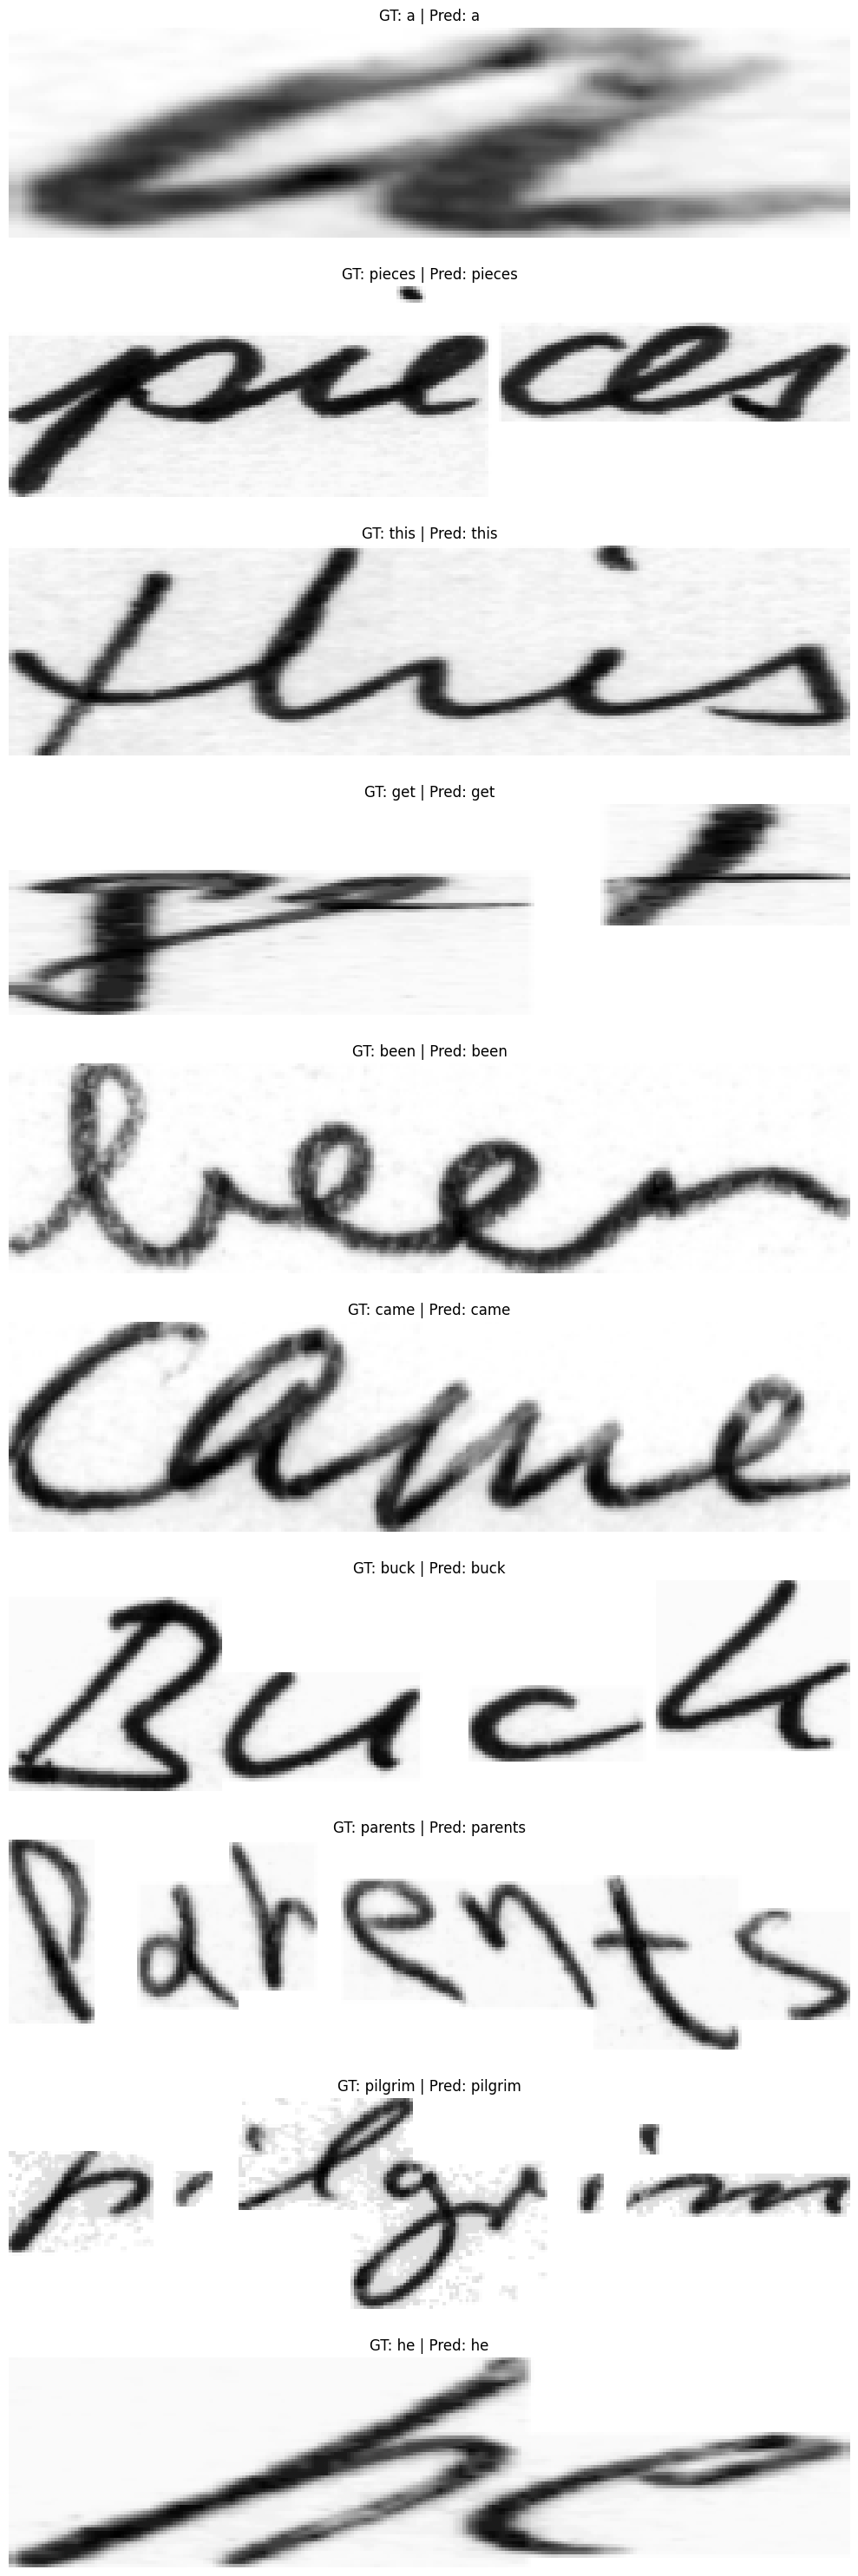

In [10]:
import random
import os

# Set checkpoint path directly for Kaggle (fixed invalid path)
checkpoint_path = '/kaggle/working/d:/IAM/model/best_encoder_decoder.pth'

# Load best model
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with CER {checkpoint['val_cer']:.4f}")

# Evaluate on validation set
model.eval()
val_loss = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Testing on Val"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing for loss
        tgt_input = labels[:, :-1]
        tgt_output = labels[:, 1:]
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        logits = model(images, tgt_input, tgt_mask=tgt_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask)
        loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        val_loss += loss.item()
        
        # Greedy decoding for metrics
        predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
        all_predictions.extend(predictions)
        all_targets.extend(labels)

val_loss /= len(val_loader)
val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)

print(f"\n{'='*60}")
print("Test Results:")
print(f"{'='*60}")
print(f"  📉 Test Loss: {val_loss:.4f}")
print(f"  📊 Test CER:  {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
print(f"  📊 Test WER:  {val_wer:.4f}")
print('='*60)

# Visualize 10 random samples
num_samples = 10
indices = random.sample(range(len(val_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3*num_samples))
for i, idx in enumerate(indices):
    img, label = val_dataset[idx]
    img_tensor = img.unsqueeze(0).to(DEVICE)  # [1, 1, H, W]
    
    with torch.no_grad():
        pred = model.generate(img_tensor, SOS_IDX, EOS_IDX, max_len=50)[0]
    
    gt_text = decode_sequence(label, idx_to_char)
    pred_text = decode_sequence(pred, idx_to_char)
    
    # Plot image
    axes[i].imshow(img.squeeze(0).numpy(), cmap='gray')
    axes[i].set_title(f"GT: {gt_text} | Pred: {pred_text}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()